# CIS 509 Presentation Model - Nashville Music Venues
## Turnaround Playbook (2013–2019)
### Team 1


In [1]:
# Mount Google Drive to access local files
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/CIS 509


Mounted at /content/drive
/content/drive/MyDrive/CIS 509


## Cell Group 1: Data Loading & Filtering


In [6]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Configuration
pd.set_option('display.max_columns', 50)
%matplotlib inline
sns.set_style('whitegrid')

print('Starting Data Pipeline...')

# 1. Load Businesses
print('Loading business data...')
business_data = []
try:
    with open('yelp_academic_dataset_business.json', 'r', encoding='utf-8') as f:
        for line in f:
            business_data.append(json.loads(line))
    business_df = pd.DataFrame(business_data)

    # Filter for Music Venues in Nashville, TN
    business_df = business_df[business_df['categories'].notna()]
    music_venues = business_df[business_df['categories'].str.lower().str.contains('music venues')]
    nashville_music = music_venues[
        (music_venues['city'].str.lower() == 'nashville') &
        (music_venues['state'] == 'TN')
    ].copy()

    target_ids = set(nashville_music['business_id'])
    print(f'Found {len(nashville_music)} Nashville music venues.')
except FileNotFoundError:
    print('Error: yelp_academic_dataset_business.json not found.')
    target_ids = set()

# 2. Load Reviews (filtered by business_id)
print('Loading reviews for target venues (this may take a moment)...')
reviews = []
try:
    if target_ids:
        with open('yelp_academic_dataset_review.json', 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    r = json.loads(line)
                    if r['business_id'] in target_ids:
                        reviews.append(r)
                except ValueError:
                    continue
    review_df = pd.DataFrame(reviews)
    print(f'Loaded {len(review_df)} raw reviews for these venues.')
except FileNotFoundError:
    print('Error: yelp_academic_dataset_review.json not found.')
    review_df = pd.DataFrame()

# 3. Filter Date (2013-2019)
if not review_df.empty:
    review_df['date'] = pd.to_datetime(review_df['date'])
    review_df = review_df[
        (review_df['date'].dt.year >= 2013) &
        (review_df['date'].dt.year <= 2019)
    ]
    print(f'Filtered to 2013-2019: {len(review_df)} reviews.')

    # Deduplicate
    review_df = review_df.drop_duplicates(subset='review_id')

    # 4. Merge Business Metadata
    full_df = pd.merge(review_df, nashville_music[['business_id', 'name', 'categories', 'stars', 'review_count']],
                      on='business_id', how='left', suffixes=('', '_biz'))

    # 5. Assign Subtypes
    def get_subtype(categories):
        if not isinstance(categories, str):
            return 'Other'
        cats = categories.lower()

        # Priority Order
        if any(x in cats for x in ['dance clubs', 'nightclubs', 'country dance halls']):
            return 'Dance/Club'
        elif any(x in cats for x in ['venues & event spaces', 'event planning & services', 'party & event planning']):
            return 'Event Space'
        elif any(x in cats for x in ['performing arts', 'concert halls', 'theaters', 'opera & ballet']):
            return 'Performance Hall/Theater'
        elif 'jazz & blues' in cats:
            return 'Jazz/Blues'
        elif any(x in cats for x in ['bars', 'pubs', 'sports bars', 'dive bars', 'cocktail bars', 'beer bar', 'wine bars', 'lounges']):
            return 'Bar-Oriented'
        elif any(x in cats for x in ['restaurants', 'food', 'breakfast & brunch']):
            return 'Restaurant-Hybrid'
        else:
            return 'Other'

    full_df['subtype'] = full_df['categories'].apply(get_subtype)

    print('\nPipeline Verification Counts:')
    print(f'Total Final Reviews: {len(full_df)}')
    print(f'Unique Businesses: {full_df["business_id"].nunique()}')
    print('\nSubtype Distribution:')
    print(full_df['subtype'].value_counts())
else:
    print('No data loaded. Check files.')
    full_df = pd.DataFrame()


Starting Data Pipeline...
Loading business data...
Found 151 Nashville music venues.
Loading reviews for target venues (this may take a moment)...
Loaded 25892 raw reviews for these venues.
Filtered to 2013-2019: 18925 reviews.

Pipeline Verification Counts:
Total Final Reviews: 18925
Unique Businesses: 139

Subtype Distribution:
subtype
Bar-Oriented                9624
Event Space                 4102
Restaurant-Hybrid           2586
Jazz/Blues                   968
Other                        729
Performance Hall/Theater     714
Dance/Club                   202
Name: count, dtype: int64


## Cell Group 2: Summary Statistics


In [13]:
if not full_df.empty:
    from nltk.tokenize import word_tokenize
    try:
        nltk.data.find('tokenizers/punkt')
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt', quiet=True)
        nltk.download('punkt_tab', quiet=True)

    # Tokenize
    print('Tokenizing reviews (this may take a minute)...')
    full_df['tokens'] = full_df['text'].apply(lambda x: word_tokenize(str(x).lower()))
    full_df['num_tokens'] = full_df['tokens'].apply(len)
    all_tokens = [t for tokens in full_df['tokens'] for t in tokens if t.isalpha()]

    print('\n=== Summary Statistics ===')
    print(f'Total Reviews:        {len(full_df):,}')
    print(f'Total Tokens:         {full_df["num_tokens"].sum():,}')
    print(f'Unique Words (vocab): {len(set(all_tokens)):,}')
    print(f'Avg Review Length (tokens): {full_df["num_tokens"].mean():.1f}')
    print(f'Median Review Length:       {full_df["num_tokens"].median():.0f}')
    print(f'Unique Reviewers:     {full_df["user_id"].nunique():,}')
    print(f'Unique Businesses:    {full_df["business_id"].nunique():,}')

    print('\n=== Ratings & Votes (Averages) ===')
    print(f'Average Stars: {full_df["stars"].mean():.2f}')
    print(f'Average Useful: {full_df["useful"].mean():.2f}')
    print(f'Average Funny:  {full_df["funny"].mean():.2f}')
    print(f'Average Cool:   {full_df["cool"].mean():.2f}')

    print('\n=== Reviews by Year ===')
    print(full_df['date'].dt.year.value_counts().sort_index())

    print('\n=== Reviews by Subtype ===')
    print(full_df['subtype'].value_counts())

Tokenizing reviews (this may take a minute)...

=== Summary Statistics ===
Total Reviews:        18,925
Total Tokens:         2,100,759
Unique Words (vocab): 25,331
Avg Review Length (tokens): 111.0
Median Review Length:       80
Unique Reviewers:     14,485
Unique Businesses:    139

=== Ratings & Votes (Averages) ===
Average Stars: 3.75
Average Useful: 0.88
Average Funny:  0.28
Average Cool:   0.46

=== Reviews by Year ===
date
2013    1583
2014    2137
2015    2535
2016    2548
2017    2661
2018    3794
2019    3667
Name: count, dtype: int64

=== Reviews by Subtype ===
subtype
Bar-Oriented                9624
Event Space                 4102
Restaurant-Hybrid           2586
Jazz/Blues                   968
Other                        729
Performance Hall/Theater     714
Dance/Club                   202
Name: count, dtype: int64


## Cell Group 3: Sentiment Analysis (VADER)


In [14]:
if not full_df.empty:
    # Ensure VADER lexicon is downloaded
    try:
        nltk.data.find('sentiment/vader_lexicon.zip')
    except LookupError:
        nltk.download('vader_lexicon')

    analyzer = SentimentIntensityAnalyzer()

    print('Running VADER sentiment analysis on all reviews...')
    full_df['vader_compound'] = full_df['text'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

    # Classification
    def classify_vader(score):
        if score >= 0.05: return 'Positive'
        elif score <= -0.05: return 'Negative'
        else: return 'Neutral'

    full_df['vader_class'] = full_df['vader_compound'].apply(classify_vader)

    # Star-based Class
    def classify_stars(stars):
        if stars >= 4: return 'Positive'
        elif stars <= 2: return 'Negative'
        else: return 'Neutral'

    full_df['star_class'] = full_df['stars'].apply(classify_stars)

    # Mismatch Analysis
    mismatches = full_df[full_df['vader_class'] != full_df['star_class']]
    mismatch_rate = len(mismatches) / len(full_df)

    low_star_pos_vader = full_df[(full_df['stars'] <= 2) & (full_df['vader_class'] == 'Positive')]
    high_star_neg_vader = full_df[(full_df['stars'] >= 4) & (full_df['vader_class'] == 'Negative')]

    print(f'Mismatch Rate: {mismatch_rate:.1%}')
    print(f'Low Star (1-2) but Positive VADER: {len(low_star_pos_vader)}')
    print(f'High Star (4-5) but Negative VADER: {len(high_star_neg_vader)}')

    print('\n--- Examples: Low Star / Positive VADER ---')
    for i, row in low_star_pos_vader.head(3).iterrows():
        print(f"Stars: {row['stars']}, VADER: {row['vader_compound']:.2f}\nText: {row['text'][:200]}...\n")

    print('\n--- Examples: High Star / Negative VADER ---')
    for i, row in high_star_neg_vader.head(3).iterrows():
        print(f"Stars: {row['stars']}, VADER: {row['vader_compound']:.2f}\nText: {row['text'][:200]}...\n")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


Running VADER sentiment analysis on all reviews...
Mismatch Rate: 24.7%
Low Star (1-2) but Positive VADER: 2014
High Star (4-5) but Negative VADER: 221

--- Examples: Low Star / Positive VADER ---
Stars: 1.0, VADER: 0.94
Text: The worst!!! We waited in line for 2 hours while they let ppl cut in front of us...when we finally get in...order drinks and food it takes 23 min to get our food..nachos....all bottom of the barrel ch...

Stars: 1.0, VADER: 0.43
Text: Probably an amazing bar- I typically LOVE Margaritaville bars, but the security guard here was SO rude and SO disrespectful, even to those doing exactly what he asked. He put a huge damper on the day ...

Stars: 2.0, VADER: 0.49
Text: I haven't been this disappointed in a restaurant for a very long time. Ole Red's is a burger and beer joint. My burger came in undercooked and wasn't really very flavorful. My wife made the same state...


--- Examples: High Star / Negative VADER ---
Stars: 5.0, VADER: -0.63
Text: This place ROCKS!!! A

## Cell Group 4: Topic Modeling (NMF on 1–2★ reviews)


In [15]:
if not full_df.empty:

    # Baseline: negative rate by subtype (1–2★ / all reviews)
    neg_rate_by_subtype = (
        full_df.assign(is_negative=full_df['stars'].isin([1, 2]))
               .groupby('subtype')['is_negative']
               .mean()
               .sort_values(ascending=False)
    )

    print('\nNegative Rate by Subtype (1–2★ / all reviews):')
    print(neg_rate_by_subtype.map(lambda x: f'{x:.1%}'))

    print('\nReview counts by subtype (all reviews):')
    print(full_df.groupby('subtype')['review_id'].count().sort_values(ascending=False))

    # Filter for Topic Modeling
    negative_reviews = full_df[full_df['stars'] <= 2].copy()
    negative_reviews = negative_reviews[negative_reviews['text'].apply(lambda x: len(x.split())) >= 10]
    print(f'Reviews for Topic Modeling (1-2 stars, >=10 tokens): {len(negative_reviews)}')

    # Stop Words Setup
    try:
        nltk.data.find('corpora/stopwords.zip')
    except LookupError:
        nltk.download('stopwords')

    stop_words = set(stopwords.words('english'))
    negation_words = {'no', 'not', "n't", 'never'}
    stop_words = stop_words - negation_words
    domain_fillers = {
        'place','go','got','went','would','one','get','like','really','even','could','also','much','back','us',
        'came','come','going','said','told','asked','know','make','made','nashville','venue','music','night','time'
    }
    stop_words = list(stop_words.union(domain_fillers))

    # TF-IDF
    print('Running TF-IDF...')
    tfidf_vectorizer = TfidfVectorizer(
        max_df=0.85,
        min_df=5,
        max_features=5000,
        ngram_range=(1, 2),
        stop_words=stop_words
    )
    tfidf = tfidf_vectorizer.fit_transform(negative_reviews['text'])
    feature_names = tfidf_vectorizer.get_feature_names_out()

    # NMF
    print('Running NMF (8 components)...')
    nmf_model = NMF(n_components=8, random_state=42, max_iter=500)
    nmf_w = nmf_model.fit_transform(tfidf)
    nmf_h = nmf_model.components_

    # Print Topics
    print('\nTop 15 terms per topic:')
    for topic_idx, topic in enumerate(nmf_h):
        top_indices = topic.argsort()[:-16:-1]
        top_terms = [feature_names[i] for i in top_indices]
        print(f'Topic {topic_idx}: { ", ".join(top_terms) }')



Negative Rate by Subtype (1–2★ / all reviews):
subtype
Dance/Club                  29.2%
Bar-Oriented                23.7%
Event Space                 22.3%
Jazz/Blues                  19.9%
Other                       16.9%
Restaurant-Hybrid           10.6%
Performance Hall/Theater     7.7%
Name: is_negative, dtype: object

Review counts by subtype (all reviews):
subtype
Bar-Oriented                9624
Event Space                 4102
Restaurant-Hybrid           2586
Jazz/Blues                   968
Other                        729
Performance Hall/Theater     714
Dance/Club                   202
Name: review_id, dtype: int64
Reviews for Topic Modeling (1-2 stars, >=10 tokens): 3903
Running TF-IDF...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Running NMF (8 components)...

Top 15 terms per topic:
Topic 0: band, good, floor, playing, country, song, live, drinks, great, cover, beer, dance, play, stage, better
Topic 1: chicken, burger, ordered, cheese, fries, fried, dry, bbq, good, pork, sandwich, eat, salad, sauce, menu
Topic 2: minutes, table, waited, order, server, waitress, took, another, 10, 30, 15, 20, finally, ordered, wait
Topic 3: bar, bartender, drink, drinks, bartenders, service, no, beer, busy, two, people, broadway, bar tender, floor, bar service
Topic 4: food, service, terrible, great, horrible, good, cold, slow, bad, worst, mediocre, food service, average, terrible service, food cold
Topic 5: rude, bouncer, id, never, security, door, friend, manager, friends, let, bouncers, leave, ever, group, guy
Topic 6: show, room, see, tickets, people, no, line, hotel, seats, parking, concert, ticket, lot, front, stage
Topic 7: not, worth, not worth, recommend, not recommend, not good, definitely, friendly, definitely not, n

## Cell Group 5: Topic Labeling
Topic labels and fixability tags are rule-based manual mappings for operational prioritization; results are directional, not causal.

In [17]:
if not full_df.empty:
    # ── First, print topics again for side-by-side verification ──
    print('=== VERIFY TOPIC LABELS MATCH TOP TERMS ===')
    print('Expected mapping (update if your topics differ):\n')

    expected_mapping = {
        0: ('Entertainment Quality',     'Structural',  'band/playing/country/song/stage'),
        1: ('Food Quality',              'Fixable Ops', 'chicken/burger/fries/bbq/sandwich'),
        2: ('Slow Service/Wait Times',   'Fixable Ops', 'minutes/waited/server/waitress/finally'),
        3: ('Bar/Drink Service',         'Fixable Ops', 'bar/bartender/drink/service/busy'),
        4: ('Food & Service Failures',   'Fixable Ops', 'food/terrible/horrible/cold/slow'),
        5: ('Bouncer/Security',          'Fixable Ops', 'rude/bouncer/id/security/door'),
        6: ('Venue Logistics',           'Structural',  'show/tickets/parking/hotel/seats'),
        7: ('General Dissatisfaction',   'Mixed',       'not worth/not recommend/not good'),
    }

    for t_id, (label, cat, expected_terms) in expected_mapping.items():
        actual_top5 = [feature_names[i] for i in nmf_h[t_id].argsort()[:-6:-1]]
        match = '✅' if any(exp in ' '.join(actual_top5) for exp in expected_terms.split('/')[0:2]) else '⚠️ CHECK'
        print(f'  T{t_id} {match}  Expected: {expected_terms}')
        print(f'       Actual top 5: {", ".join(actual_top5)}')
        print(f'       → Label: {label} ({cat})\n')

    # ── Apply labels (update dict if verification shows misalignment) ──
    topic_labels = {
        0: {'label': 'Entertainment Quality',     'category': 'Structural'},
        1: {'label': 'Food Quality',              'category': 'Fixable Ops'},
        2: {'label': 'Slow Service/Wait Times',   'category': 'Fixable Ops'},
        3: {'label': 'Bar/Drink Service',         'category': 'Fixable Ops'},
        4: {'label': 'Food & Service Failures',   'category': 'Fixable Ops'},
        5: {'label': 'Bouncer/Security',          'category': 'Fixable Ops'},
        6: {'label': 'Venue Logistics',           'category': 'Structural'},
        7: {'label': 'General Dissatisfaction',   'category': 'Mixed'},
    }

    # Assign dominant topic
    dominant_topics = nmf_w.argmax(axis=1)
    negative_reviews['dominant_topic_id'] = dominant_topics
    negative_reviews['topic_label'] = negative_reviews['dominant_topic_id'].map(lambda x: topic_labels[x]['label'])
    negative_reviews['fixability'] = negative_reviews['dominant_topic_id'].map(lambda x: topic_labels[x]['category'])

    print('\n=== Topic Distribution ===')
    print(negative_reviews['topic_label'].value_counts())

    print('\n=== Fixability Distribution ===')
    fix_dist = negative_reviews['fixability'].value_counts()
    fix_pct = negative_reviews['fixability'].value_counts(normalize=True) * 100
    for cat in fix_dist.index:
        print(f'  {cat:15s}  {fix_dist[cat]:,} reviews  ({fix_pct[cat]:.1f}%)')


=== VERIFY TOPIC LABELS MATCH TOP TERMS ===
Expected mapping (update if your topics differ):

  T0 ✅  Expected: band/playing/country/song/stage
       Actual top 5: band, good, floor, playing, country
       → Label: Entertainment Quality (Structural)

  T1 ✅  Expected: chicken/burger/fries/bbq/sandwich
       Actual top 5: chicken, burger, ordered, cheese, fries
       → Label: Food Quality (Fixable Ops)

  T2 ✅  Expected: minutes/waited/server/waitress/finally
       Actual top 5: minutes, table, waited, order, server
       → Label: Slow Service/Wait Times (Fixable Ops)

  T3 ✅  Expected: bar/bartender/drink/service/busy
       Actual top 5: bar, bartender, drink, drinks, bartenders
       → Label: Bar/Drink Service (Fixable Ops)

  T4 ✅  Expected: food/terrible/horrible/cold/slow
       Actual top 5: food, service, terrible, great, horrible
       → Label: Food & Service Failures (Fixable Ops)

  T5 ✅  Expected: rude/bouncer/id/security/door
       Actual top 5: rude, bouncer, id, 

## Cell Group 6: Actionability Index


In [18]:
if not full_df.empty:
    # Calculate Actionability: % of Fixable Ops among Negative Reviews

    def calculate_actionability(df):
        total = len(df)
        if total == 0: return 0
        fixable = len(df[df['fixability'] == 'Fixable Ops'])
        return fixable / total

    # By Subtype and Year
    negative_reviews['year'] = negative_reviews['date'].dt.year
    actionability_pivot = negative_reviews.pivot_table(
        index='subtype',
        columns='year',
        values='fixability',
        aggfunc=lambda x: calculate_actionability(pd.DataFrame({'fixability': x}))
    )

    # Count for confidence threshold
    count_pivot = negative_reviews.pivot_table(
        index='subtype',
        columns='year',
        values='review_id',
        aggfunc='count'
    )

    print('Actionability Index (By Year & Subtype):')
    display(actionability_pivot.style.format('{:.1%}').background_gradient(cmap='Greens'))

    print('\nReview Counts (Check for <10):')
    display(count_pivot)

    print('\nTotal Negative Review Counts by Subtype:')
    print(negative_reviews.groupby('subtype')['review_id'].count().sort_values(ascending=False))

    # Overall Actionability by Subtype
    overall_actionability = negative_reviews.groupby('subtype').apply(
        lambda x: calculate_actionability(x)
    ).sort_values(ascending=False)

    print('\nOverall Actionability by Subtype:')
    print(overall_actionability)


Actionability Index (By Year & Subtype):


year,2013,2014,2015,2016,2017,2018,2019
subtype,,,,,,,
Bar-Oriented,72.4%,73.8%,81.1%,74.3%,78.7%,77.4%,79.6%
Dance/Club,28.6%,75.0%,0.0%,100.0%,70.0%,81.8%,100.0%
Event Space,59.3%,57.0%,61.8%,57.4%,45.2%,72.6%,66.8%
Jazz/Blues,60.0%,73.7%,78.9%,84.6%,81.8%,80.8%,83.0%
Other,50.0%,61.5%,42.9%,17.6%,27.8%,38.2%,29.4%
Performance Hall/Theater,0.0%,0.0%,0.0%,25.0%,0.0%,6.2%,0.0%
Restaurant-Hybrid,67.5%,85.2%,67.2%,80.6%,65.2%,63.0%,58.3%



Review Counts (Check for <10):


year,2013,2014,2015,2016,2017,2018,2019
subtype,,,,,,,
Bar-Oriented,123,202,264,276,361,483,573
Dance/Club,7,4,1,1,10,33,3
Event Space,54,93,110,129,84,241,205
Jazz/Blues,10,19,19,39,33,26,47
Other,10,13,14,17,18,34,17
Performance Hall/Theater,6,4,2,4,9,16,14
Restaurant-Hybrid,40,54,64,31,23,27,36



Total Negative Review Counts by Subtype:
subtype
Bar-Oriented                2282
Event Space                  916
Restaurant-Hybrid            275
Jazz/Blues                   193
Other                        123
Dance/Club                    59
Performance Hall/Theater      55
Name: review_id, dtype: int64

Overall Actionability by Subtype:
subtype
Jazz/Blues                  0.803109
Bar-Oriented                0.776074
Dance/Club                  0.728814
Restaurant-Hybrid           0.705455
Event Space                 0.629913
Other                       0.365854
Performance Hall/Theater    0.036364
dtype: float64


/tmp/ipython-input-4027638101.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_actionability = negative_reviews.groupby('subtype').apply(


## Cell Group 7: Presentation-Ready Charts


/tmp/ipython-input-2812030249.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=full_df, y='subtype', order=order, palette='viridis')


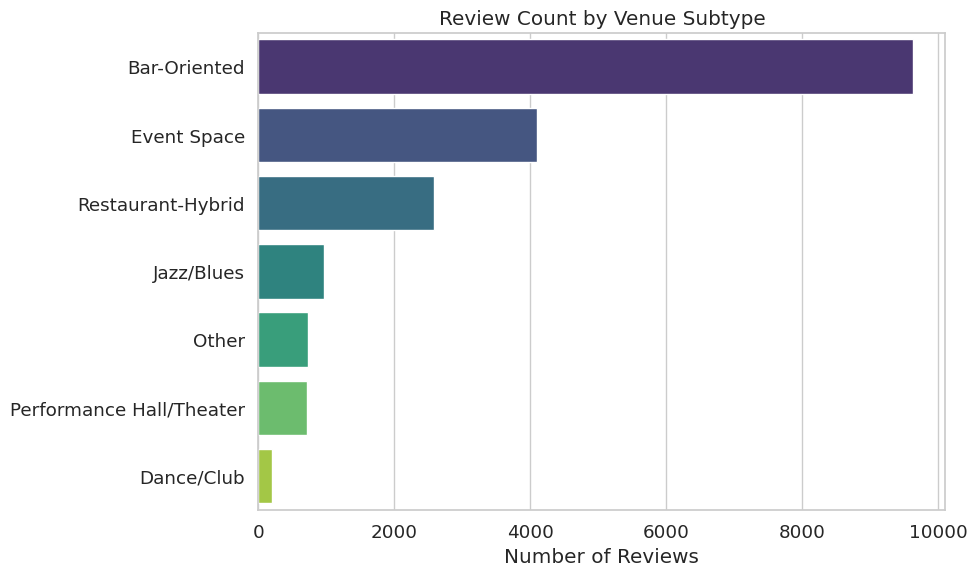

/tmp/ipython-input-2812030249.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=full_df, x='stars', palette='Blues_d')


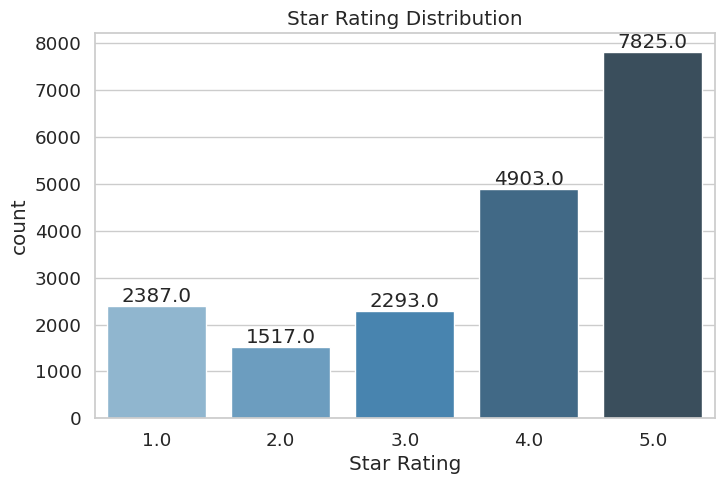

/tmp/ipython-input-2812030249.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neg_rate.values, y=neg_rate.index, palette='RdYlGn_r')


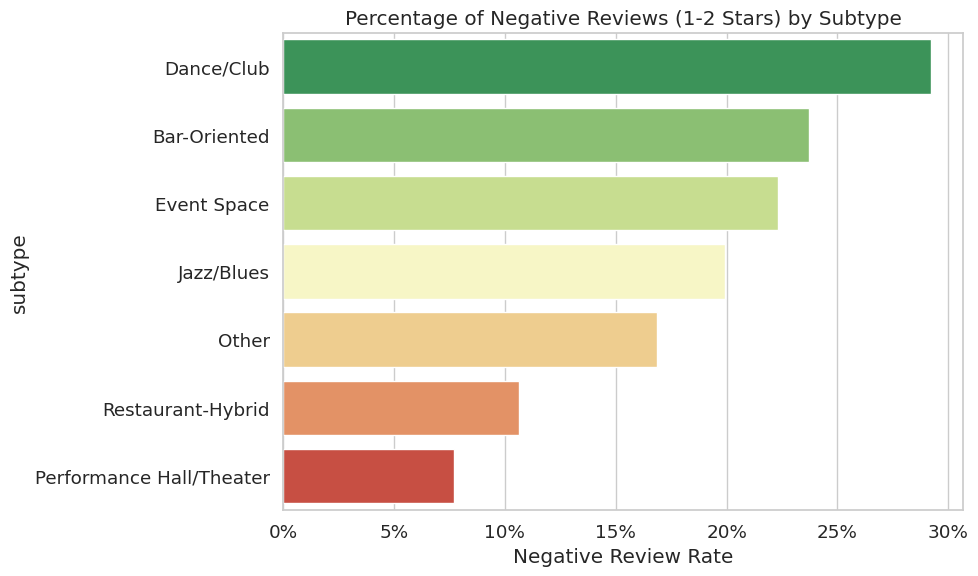

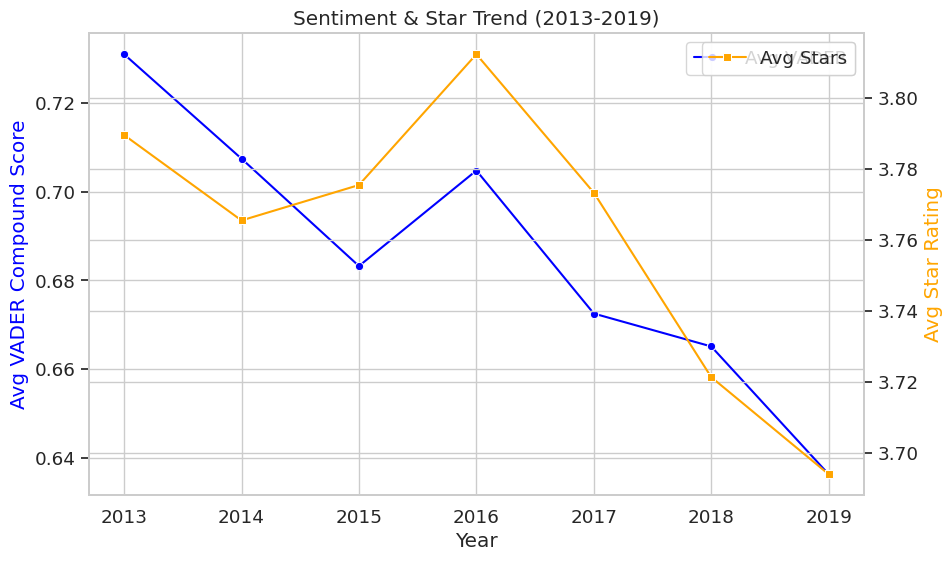

/tmp/ipython-input-2812030249.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=topic_counts.values, palette=cat_colors)


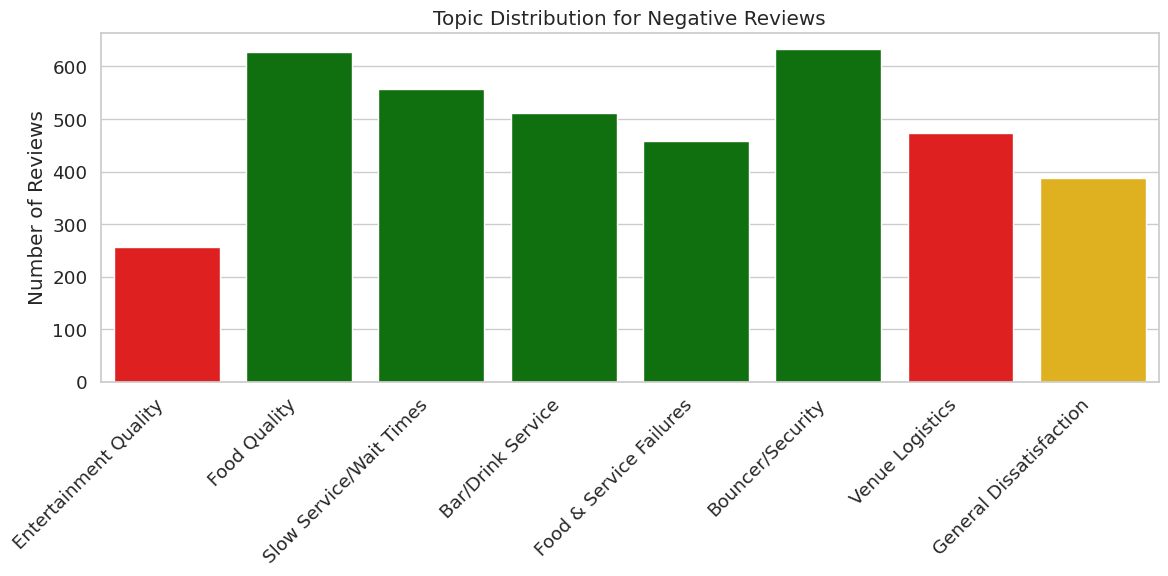

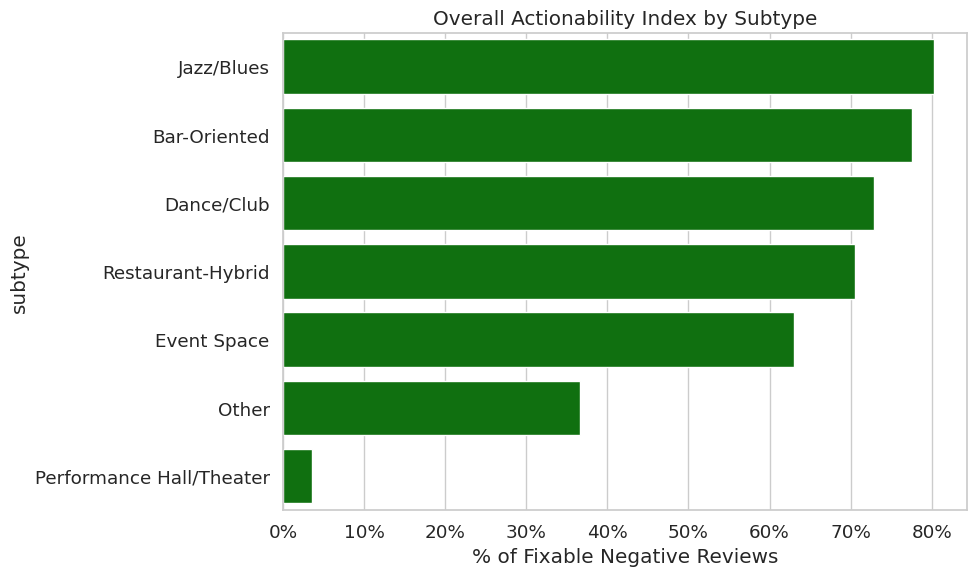

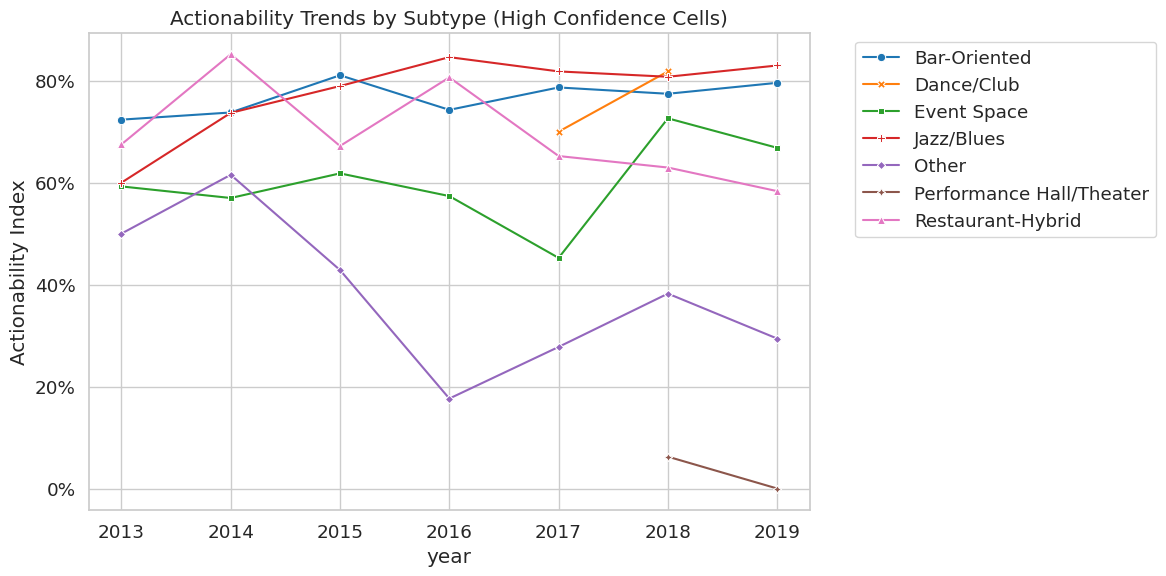

In [19]:
if not full_df.empty:
    # Setup
    colors = {'Fixable Ops': 'green', 'Structural': 'red', 'Mixed': '#FFC000', 'General': 'blue'}
    sns.set_context('notebook', font_scale=1.2)
    sns.set_style('whitegrid')

    # 1. Subtype Breakdown
    plt.figure(figsize=(10, 6))
    order = full_df['subtype'].value_counts().index
    sns.countplot(data=full_df, y='subtype', order=order, palette='viridis')
    plt.title('Review Count by Venue Subtype')
    plt.xlabel('Number of Reviews')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

    # 2. Star Distribution
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=full_df, x='stars', palette='Blues_d')
    plt.title('Star Rating Distribution')
    plt.xlabel('Star Rating')
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
    plt.show()

    # 3. Negative Rate by Subtype
    neg_rate = full_df.groupby('subtype')['stars'].apply(lambda x: (x <= 2).mean()).sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=neg_rate.values, y=neg_rate.index, palette='RdYlGn_r')
    plt.title('Percentage of Negative Reviews (1-2 Stars) by Subtype')
    plt.xlabel('Negative Review Rate')
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
    plt.tight_layout()
    plt.show()

    # 4. Sentiment Over Time (Dual Axis)
    time_stats = full_df.groupby(full_df['date'].dt.year).agg({'vader_compound':'mean', 'stars':'mean'})
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()
    sns.lineplot(data=time_stats, x=time_stats.index, y='vader_compound', ax=ax1, color='blue', marker='o', label='Avg VADER')
    sns.lineplot(data=time_stats, x=time_stats.index, y='stars', ax=ax2, color='orange', marker='s', label='Avg Stars')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Avg VADER Compound Score', color='blue')
    ax2.set_ylabel('Avg Star Rating', color='orange')
    ax1.set_title('Sentiment & Star Trend (2013-2019)')
    plt.show()

    # 5. Topic Distribution (Colored)
    topic_counts = negative_reviews['dominant_topic_id'].value_counts().sort_index()
    labels = [topic_labels[i]['label'] for i in topic_counts.index]
    cat_colors = [colors[topic_labels[i]['category']] for i in topic_counts.index]

    plt.figure(figsize=(12, 6))
    sns.barplot(x=labels, y=topic_counts.values, palette=cat_colors)
    plt.xticks(rotation=45, ha='right')
    plt.title('Topic Distribution for Negative Reviews')
    plt.ylabel('Number of Reviews')
    plt.tight_layout()
    plt.show()

    # 6. Actionability by Subtype
    plt.figure(figsize=(10, 6))
    sns.barplot(x=overall_actionability.values, y=overall_actionability.index, color='green')
    plt.title('Overall Actionability Index by Subtype')
    plt.xlabel('% of Fixable Negative Reviews')
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
    plt.tight_layout()
    plt.show()

    # 7. Actionability Over Time (Line Chart)
    plt.figure(figsize=(12, 6))
    # Filter out points with low confidence (<10 reviews)
    mask = count_pivot >= 10
    plot_data = actionability_pivot[mask]
    sns.lineplot(data=plot_data.T, markers=True, dashes=False)
    plt.title('Actionability Trends by Subtype (High Confidence Cells)')
    plt.ylabel('Actionability Index')
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## Cell Group 8: Key Findings Summary

### Business Context
- **Total Venues Analyzed**: 139 Nashville music venues (from 151 in dataset, 139 with reviews in 2013–2019)
- **Total Reviews**: 18,925 deduplicated reviews across 7 years
- **Unique Reviewers**: 14,485
- **Vocabulary**: 25,331 unique words across 2.1M tokens
- **Average Review Length**: 111 tokens (median 80)
- **Average Star Rating**: 3.75
- **Review Volume Growth**: 1,583 (2013) → 3,794 (2018) — a 2.4× increase during Nashville's tourism boom
- **Dominant Subtype**: Bar-Oriented (9,624 reviews, 51% of dataset, 69 venues)

### Research Question & Mismatch Insight
- **Question**: "What drives negative reviews at Nashville music venues, and how much is operationally fixable?"
- **Sentiment-Star Mismatch Rate**: 24.7% (4,668 reviews)
- **Critical finding**: 2,014 reviews gave 1–2 stars but had positive VADER sentiment — reviewers praised some aspects but still rated low, signaling specific operational friction rather than holistic dissatisfaction
- **Stakeholders**: venue operators (fix what's broken), booking agents (pick better venues), investors (identify turnaround candidates)

### Data Pipeline Funnel
- 150,346 total Yelp businesses → 1,104 Music Venues → 151 Nashville, TN → 18,925 reviews (2013–2019, deduplicated) → 3,903 negative reviews (1–2★, ≥10 tokens) for topic modeling

### Topic Model Results (NMF, 8 topics on 3,903 negative reviews)
- **71.4% of negative reviews are driven by Fixable Ops topics**
- 18.7% Structural, 9.9% Mixed

| Rank | Topic | Category | Reviews |
|------|-------|----------|---------|
| 1 | Bouncer/Security/Door Policy | Fixable Ops | 633 |
| 2 | Food Quality | Fixable Ops | 627 |
| 3 | Slow Service/Wait Times | Fixable Ops | 558 |
| 4 | Bar/Drink Service | Fixable Ops | 511 |
| 5 | Food & Service Failures | Fixable Ops | 458 |
| 6 | Venue Logistics/Parking/Tickets | Structural | 473 |
| 7 | General Dissatisfaction | Mixed | 387 |
| 8 | Entertainment Quality/Band Fit | Structural | 256 |

### Actionability Rankings by Subtype
| Subtype | Actionability | Negative Reviews | Interpretation |
|---------|--------------|-----------------|----------------|
| Jazz/Blues | 80.3% | 193 | Most fixable — service and food dominate complaints |
| Bar-Oriented | 77.6% | 2,282 | High volume + high fixability = biggest turnaround opportunity |
| Dance/Club | 72.9% | 59 | Low confidence (small n) |
| Restaurant-Hybrid | 70.5% | 275 | Food quality is the clear fix target |
| Event Space | 63.0% | 916 | Mix of fixable and structural (logistics) |
| Other | 36.6% | 123 | More structural complaints |
| Performance Hall/Theater | 3.6% | 55 | Almost entirely structural — not fixable by operators |

### Top 4 Managerial Recommendations
1. **Retrain door staff and standardize security policies** — Bouncer/Security is the #1 complaint topic (633 reviews). Rude bouncers and inconsistent ID policies are driving 1-star reviews at otherwise decent venues.
2. **Fix food quality or stop serving food** — Food Quality (627) and Food & Service Failures (458) together account for 1,085 negative reviews. If food isn't core to your business, cut it rather than serve bad food.
3. **Reduce wait times** — Slow Service (558 reviews) is universal across subtypes. Staff scheduling, POS upgrades, and mobile ordering are low-cost high-impact fixes.
4. **Invest in bar service training on Broadway** — Bar/Drink Service (511 reviews) specifically calls out Broadway bartenders. Speed, attitude, and drink quality are the levers.

### Limitations
- Single city (Nashville) — findings may not generalize to other markets
- Yelp-only — misses Google, TripAdvisor, and non-reviewing customers
- Topic labeling (Fixable vs Structural) involves subjective judgment
- Survivorship bias — closed venues underrepresented in later years
- Tourist vs local bias — Nashville's heavy tourism may inflate novelty-driven ratings

### Future Work
- Multi-city comparison (Nashville vs Austin vs New Orleans)
- Post-COVID extension (2020–2022) to track recovery patterns
- Transformer-based sentiment models (RoBERTa) as robustness check
- Venue-level (not just subtype-level) actionability scoring
